In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [17]:
modeling_data = pd.read_csv('final_youtube.csv', sep = ',')
modeling_data

,Unnamed: 0,views,likes,comments,duration_log,bitrate_log,height_log,width_log,frame rate_log,views_log,...,video_quality_score,file_size_estimate,frame_density,is_hd,is_full_hd,is_4k,is_short,is_medium,is_long,content_score
0,0,4078,41,3,5.198497,8.661813,7.560601,6.985642,3.258097,8.313607,...,16.222414,13.860310,8.456594,1,1,0,0,1,0,2
1,1,33,2,1,6.836259,7.086738,7.155396,6.580639,3.433987,3.526361,...,14.242134,13.922997,10.270246,1,1,0,0,0,1,2
2,2,13227,135,17,5.455321,8.015988,7.155396,6.580639,3.218076,9.490091,...,15.171384,13.471309,8.673397,1,1,0,0,1,0,2
3,3,43,1,0,6.333280,6.068426,5.771441,5.484797,3.433019,3.784190,...,11.839867,12.401705,9.766299,0,0,0,0,1,0,2
4,4,222,2,0,5.707110,8.035279,7.155396,6.580639,3.218076,5.407172,...,15.190675,13.742389,8.925186,1,1,0,0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17581,17581,27,0,0,6.349139,7.159292,6.463029,6.175867,3.431403,3.332205,...,13.622321,13.508431,9.780542,0,0,0,0,1,0,1
17582,17582,295,1,0,4.663439,6.734592,6.463029,6.175867,3.433019,5.690359,...,13.197621,11.398031,8.096458,0,0,0,0,1,0,0
17583,17583,770,3,0,5.087596,6.825460,6.463029,6.175867,3.433019,6.647688,...,13.288489,11.913056,8.520615,0,0,0,0,1,0,1
17584,17584,42,1,0,5.676754,8.495561,7.560601,6.985642,3.433019,3.761200,...,16.056162,14.172315,9.109773,1,1,0,0,1,0,2


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Định nghĩa lại pipeline
pipeline = Pipeline([
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Thu hẹp không gian tìm kiếm để chạy nhanh hơn
param_dist = {
    'rf__n_estimators': [50, 100],        # Giảm số lượng cây để train nhanh hơn
    'rf__max_depth': [10, 20],            # Giới hạn độ sâu của cây
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4],
    'rf__max_features': ['sqrt', 'log2']  # Bỏ 'None' vì nó tốn tài nguyên nhất
}

# Thiết lập RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10,             # Giảm xuống 10 tổ hợp tốt nhất (thay vì 20)
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Đang tìm kiếm tham số tối ưu (cấu hình nhanh)... (Vui lòng đợi 1-2 phút)")
random_search.fit(X_train, y_train)

best_pipeline = random_search.best_estimator_
print(f"\nBest params: {random_search.best_params_}")
print(f"Best CV R2 score: {random_search.best_score_:.4f}")

Đang tìm kiếm tham số tối ưu (cấu hình nhanh)... (Vui lòng đợi 1-2 phút)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best params: {'rf__n_estimators': 100, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': 20}
Best CV R2 score: 0.8317


In [19]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Dự đoán với model tốt nhất
y_train_pred_log = best_pipeline.predict(X_train)
y_test_pred_log = best_pipeline.predict(X_test)

# Đánh giá
r2_train = r2_score(y_train, y_train_pred_log)
r2_test = r2_score(y_test, y_test_pred_log)
mse_test = mean_squared_error(y_test, y_test_pred_log)

print(f"--- Optimized Model Performance ---")
print(f"Train R²: {r2_train:.4f}")
print(f"Test R²:  {r2_test:.4f}")
print(f"Test MSE: {mse_test:.4f}")

overfit_diff = r2_train - r2_test
print(f"Overfit:  {overfit_diff:.4f}")

--- Optimized Model Performance ---
Train R²: 0.9356
Test R²:  0.8193
Test MSE: 0.4291
Overfit:  0.1162


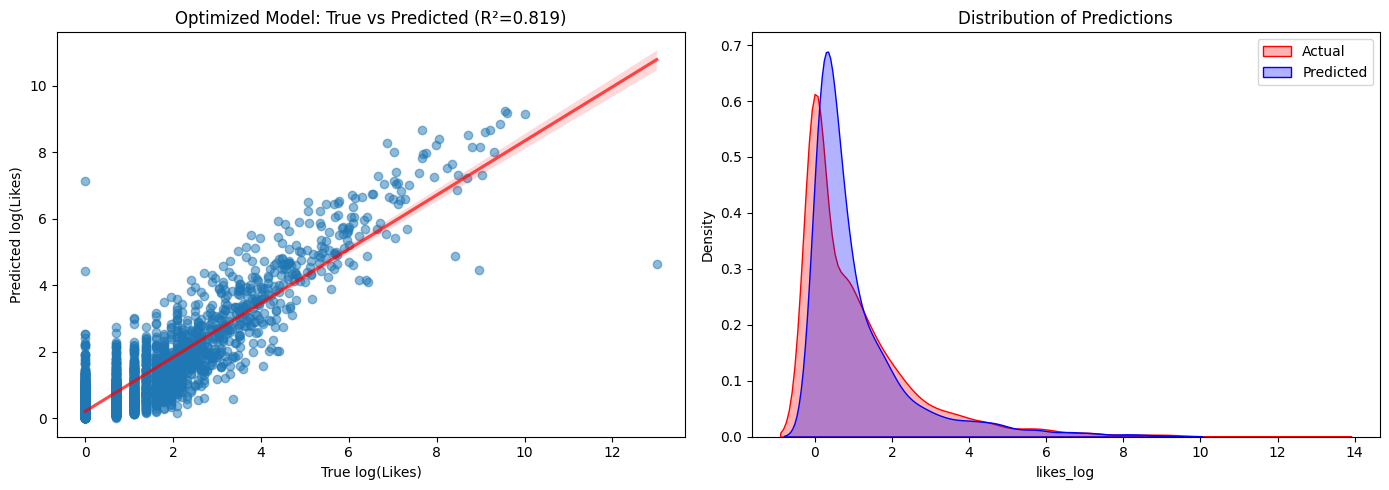

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ biểu đồ đánh giá cho model tối ưu
plt.figure(figsize=(14, 5))

# Regression Plot
plt.subplot(1, 2, 1)
sns.regplot(x=y_test, y=y_test_pred_log, line_kws={'color':'red', 'alpha':0.7}, scatter_kws={'alpha':0.5})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title(f"Optimized Model: True vs Predicted (R²={r2_test:.3f})")

# Distribution Plot
plt.subplot(1, 2, 2)
sns.kdeplot(y_test, color='red', label='Actual', fill=True, alpha=0.3)
sns.kdeplot(y_test_pred_log, color='blue', label='Predicted', fill=True, alpha=0.3)
plt.title("Distribution of Predictions")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17586 entries, 0 to 17585
Data columns (total 71 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17586 non-null  int64  
 1   views                     17586 non-null  int64  
 2   likes                     17586 non-null  int64  
 3   comments                  17586 non-null  int64  
 4   duration_log              17586 non-null  float64
 5   bitrate_log               17586 non-null  float64
 6   height_log                17586 non-null  float64
 7   width_log                 17586 non-null  float64
 8   frame rate_log            17586 non-null  float64
 9   views_log                 17586 non-null  float64
 10  likes_log                 17586 non-null  float64
 11  comments_log              17586 non-null  float64
 12  likes_log_win             17586 non-null  float64
 13  comments_log_win          17586 non-null  float64
 14  durati

# Loại bỏ các cột có thể dẫn đến data leakage

In [22]:
leakage_features = [
    # Engagement metrics (phụ thuộc views)
    'views', 'comments'
    'likes_log',
    'likes_log_win',

    # Scaled versions của engagement
    'likes_log_scaled', 'likes_log_minmax', 'likes_log_zscore',
    'likes_log_win_scaled', 'likes_log_win_minmax', 'likes_log_win_zscore',

    # Other
    'Unnamed: 0',
]

# Loại bỏ các cột tồn tại
existing_leakage = [col for col in leakage_features if col in modeling_data.columns]
df_clean = modeling_data.drop(columns=existing_leakage, errors='ignore')

print(f"Removed {len(existing_leakage)} leakage features")
print(f"Remaining: {df_clean.shape[1]} columns")

Removed 9 leakage features
Remaining: 62 columns


# Giữ lại 1 loại chuẩn hoá cho biến số, tránh multicollinearity

In [23]:
# Ưu tiên giữ _scaled, loại _minmax và _zscore
duplicate_features = []

for col in df_clean.columns:
    if '_minmax' in col:
        duplicate_features.append(col)
    elif '_zscore' in col:
        scaled_version = col.replace('_zscore', '_scaled')
        if scaled_version in df_clean.columns:
            duplicate_features.append(col)

df_clean = df_clean.drop(columns=duplicate_features, errors='ignore')

print(f"Removed {len(duplicate_features)} duplicate transforms")
print(f"Remaining: {df_clean.shape[1]} columns")

Removed 14 duplicate transforms
Remaining: 48 columns


# Chuẩn bị data cho huấn luyện

In [24]:
# Target
y = df_clean['likes_log']

# Features
X = df_clean.drop(columns=['likes_log', 'likes'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"Split ratio: 80/20")

X shape: (17586, 46)
y shape: (17586,)
Train set: (14068, 46)
Test set:  (3518, 46)
Split ratio: 80/20


# Tạo pipeline huấn luyện

In [25]:
pipeline = Pipeline([
    ("rf", RandomForestRegressor(
        random_state=42,
        n_jobs=-1              # dùng tất cả CPU cores
    ))
])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)


In [26]:
y_train_pred_log = pipeline.predict(X_train)
y_test_pred_log = pipeline.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

# Đánh giá trên tập kiểm thử và huấn luyện

In [27]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.9765          0.8243
MSE                           0.0588          0.4174
RMSE                          0.2425          0.6460
MAE                           0.1723          0.4723

Overfit (R² diff)             0.1522
   ⚠️ Model có dấu hiệu overfit


# Plot đánh giá

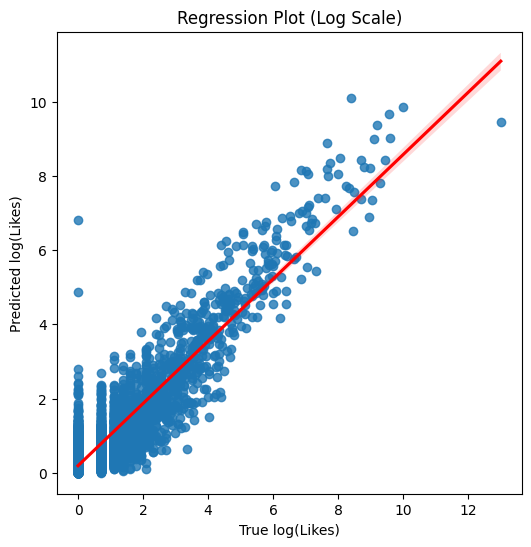

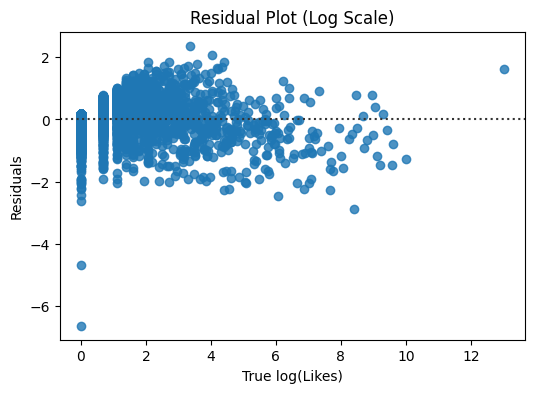

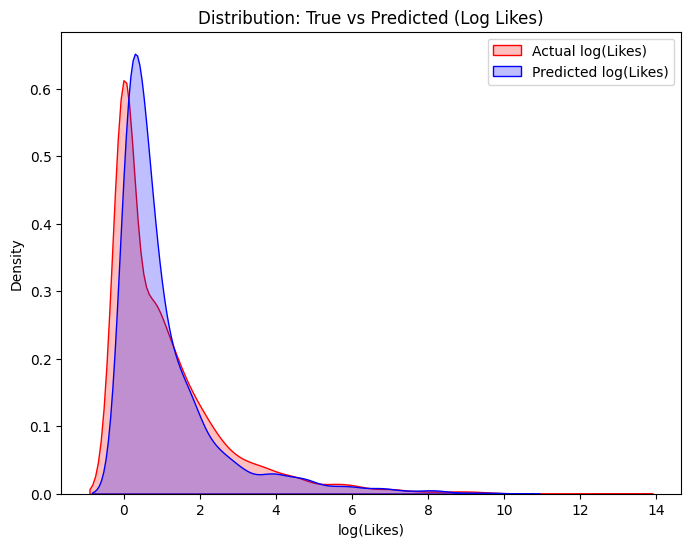

In [28]:
y_true = y_test
y_pred = y_pred
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

# ----- Distribution comparison -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [29]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, 30, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# Dùng RandomizedSearchCV thay vì GridSearchCV để nhanh hơn
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,             # Chỉ thử ngẫu nhiên 20 tổ hợp tốt nhất
    cv=3,                  # Giảm xuống 3 fold validation để tiết kiệm thời gian
    scoring='r2',
    n_jobs=-1,             # Dùng tất cả CPU cores
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

best_pipeline = random_search.best_estimator_
print(f"Best params: {random_search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

In [30]:
y_train_pred_log = best_pipeline.predict(X_train)
y_test_pred_log = best_pipeline.predict(X_test)

# Chuyển ngược lại về scale gốc nếu cần so sánh thực tế
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

In [31]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.9356          0.8193
MSE                           0.1609          0.4291
RMSE                          0.4011          0.6551
MAE                           0.2914          0.4752

Overfit (R² diff)             0.1162
   ⚠️ Model có dấu hiệu overfit


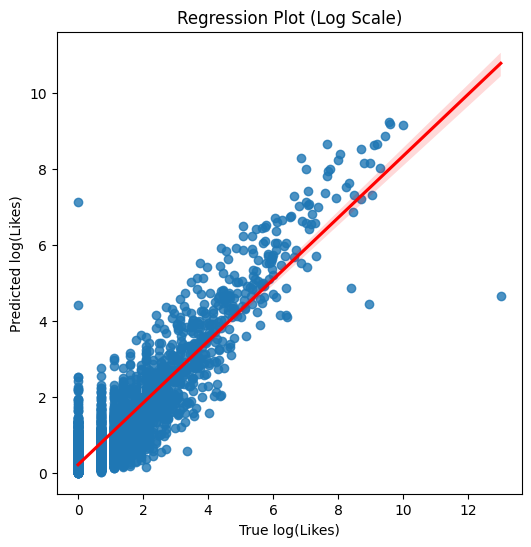

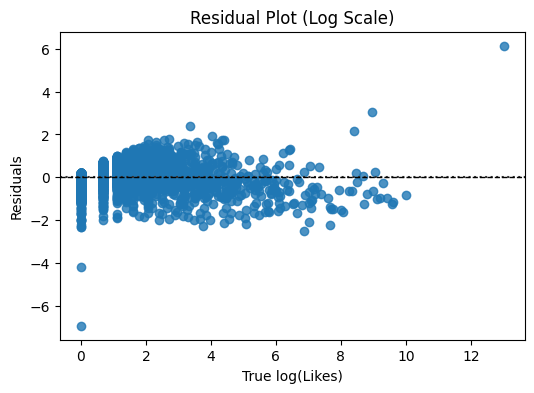

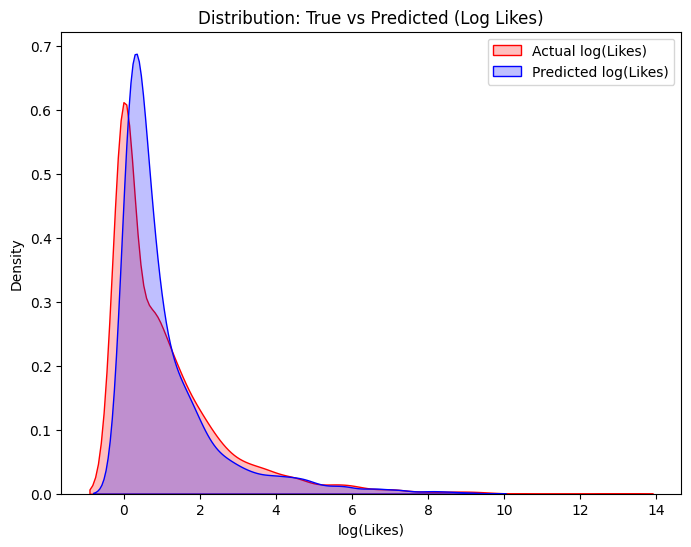

In [32]:
y_true = y_test
y_pred = y_test_pred_log
residuals = y_true - y_pred

plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()